In [3]:
import torch
import math
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.transforms.v2 as v2
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.nn.functional as F


#### Training DDPM:
the goal is to train a single denoiser for all noise levels:

Training Algorithm for DDPM:  

Repeat until convergence:  

1. Pick a random time stamp $t \sim {Unif}[1, \dots, T]$ 

2. Draw $x_{t} \sim \mathcal{N}(x_{t}|\sqrt{\bar{\alpha}_t} x_0, 1 - \bar{\alpha}_t I)$

3. Perform SGD on $ \nabla_\theta \left\| \epsilon - \epsilon_\theta \left( \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon, t \right) \right\|^2$


### 1. 前向扩散与噪声调度器

Forward process require no training, it is a determined stochastic process based on： $$x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon$$

In [3]:
class DiffusionProcess(nn.Module):
    def __init__(self,T = 1000, beta_1 =1e-4, beta_T = 0.02):
        super().__init__()
        self.T = T

        beta = torch.linspace(beta_1,beta_T,T)
        alpha = 1 - beta
        alpha_bar = torch.cumprod(alpha, dim = 0)
        #因为这两个intermediate不是model parameter,所以作为buffer存起来
        self.register_buffer("sqrt_alpha_bar",torch.sqrt(alpha_bar))
        self.register_buffer("sqrt_one_minus_alpha_bar",torch.sqrt(1 - alpha_bar))

    def _extract(self,a ,t, x_shape):
        batch_size = t.shape[0]
        #robust版本的a[t]
        out = a.gather(-1, t)
        #返回[B,1,1,1]
        return out.reshape(batch_size, *((1,) * (len(x_shape) - 1)))

    def q_sample(self,x_0,t,epsilon):
        if epsilon is None:
            epsilon = torch.randn_like(x_0)
        
        sqrt_alpha_bar_t = self._extract(self.sqrt_alpha_bar, t, x_0.shape)
        sqrt_one_minus_alpha_bar_t = self._extract(self.sqrt_one_minus_alpha_bar, t, x_0.shape)
        return sqrt_alpha_bar_t * x_0 + sqrt_one_minus_alpha_bar_t * epsilon
    

### 2. 数据加载与预处理

In [4]:
batch_size = 64

Training_data = torchvision.datasets.CIFAR10(
    root = "./data",
    train = True,
    download= True,
    transform= v2.Compose([v2.RandomHorizontalFlip(p = 0.5),v2.ToImage(),v2.ToDtype(torch.float32,scale = True),v2.Normalize(mean=[0.5,0.5,0.5],std=[0.5,0.5,0.5])])
    )

Loaded_data = DataLoader(
    Training_data,
    shuffle = True,
    batch_size = batch_size,
    drop_last = True,
    num_workers = 4,
    pin_memory = True
)

Files already downloaded and verified


### 3. 逆向去噪网络

To introduce timestep into UNet, we introduce Sinusoidal Position Embedding by wrapping time in different frequency sinusoidals, such that the added vector contains information of different time scales. We transform timestep t into vector:
$$PE_{(t,2i)} = \sin(\frac{t}{10000^{\frac{2i}{d}}})$$
$$PE_{(t,2i+1)} = \cos(\frac{t}{10000^{\frac{2i}{d}}})$$
where d is the dimension we map to, and i is a key for dimension, from 0 to $\frac{d}{2}-1$. This, we slip total dimension in half, where half of it is sin and the other half is cos.

#### Time Embedding

In [5]:
class TimeEmbedding(nn.Module):
    def __init__(self,dim):
        super().__init__()
        self.dim = dim
        #进一步放大dimension
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Linear(dim * 4, dim * 4)
        )

    def forward(self, t):
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        freqs = torch.exp(torch.arange(half_dim, device = t.device) * emb)
        #把t和emb转成t行一列和dim列一行的两个张量方便计算
        args = t.unsqueeze(-1).float() * freqs.unsqueeze(0)
        #拼接sin和cos的分量
        embedding = torch.cat([torch.sin(args),torch.cos(args)],dim =-1)
        #最后输出形状为[B,dim*4]的高维向量
        return self.mlp(embedding)
        

#### Residual Block

In [6]:
class ResnetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        #x的维度是[B,C,H,W],t的维度是[B,C]
        super().__init__()

        self.image_stack = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding = 1),
            #不用batchnorm因为1.分布式训练导致batch太小了，无法收敛 2.时间步t差异巨大，会导致特征分布差异大
            nn.GroupNorm(8,out_channels),
            nn.SiLU()
        )

        self.time_stack = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_dim, out_channels)
        )

        self.combine = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(8,out_channels)
        )

        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x, time_emb):
        h = self.image_stack(x)
        t_emb = self.time_stack(time_emb)
        #在t的维度[B,C]后面加两个维度和h的维度对齐
        t_emb = t_emb.unsqueeze(-1).unsqueeze(-1)
        #这里保持batch size和channel数不变，在每个通道里对每个像素点加上time embedding的偏执，这里pytorch会自动把emb复制图片维度份，这样每个像素都能加上偏置
        h = h + t_emb

        h = self.combine(h)

        return h + self.shortcut(x) #残差连接




#### U-Net

In [7]:
class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()
        image_channels = 3
        down_channels = (64, 128, 256, 512)
        up_channels = (512, 256, 128, 64)
        out_dim = 3
        
        
        time_base_dim = 32
        # 经过TimeEmbedding 放大后，最终的时间向量维度是128
        self.time_embedding = TimeEmbedding(time_base_dim)
        time_emb_dim = time_base_dim * 4 

        # 1. 编码器（下采样）
        self.downs = nn.ModuleList([])
        self.downsamples = nn.ModuleList([])
        in_ch = image_channels
        for out_ch in down_channels:
            self.downs.append(ResnetBlock(in_ch, out_ch, time_emb_dim))
            self.downsamples.append(nn.MaxPool2d(2)) # 每一层后面都配一个下采样
            in_ch = out_ch

        # 2. 中间层（Mid Block）- 承上启下，处理最底层的抽象特征
        self.mid_block = ResnetBlock(down_channels[-1], down_channels[-1], time_emb_dim)


        # 3. 解码器（上采样）
        self.ups = nn.ModuleList([])
        self.upsamples = nn.ModuleList([])
        in_ch = down_channels[-1]
        # 我们需要编码器各层通道数来计算拼接后的通道数，这里将其反转
        reversed_down_channels = down_channels[::-1]
        for i, out_ch in enumerate(up_channels):
            # ConvTranspose2d应该将输入通道数(in_ch)转换为目标输出通道数(out_ch)
            self.upsamples.append(nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2))
             
            # ResnetBlock的输入通道数 = 上采样后的通道数(out_ch) + skip connection的通道数
            resnet_input_channels = out_ch + reversed_down_channels[i]
            self.ups.append(ResnetBlock(resnet_input_channels, out_ch, time_emb_dim))
             
            # 为下一次迭代更新输入通道数
            in_ch = out_ch



        # 4. 输出投影
        self.final_conv = nn.Conv2d(up_channels[-1], out_dim, 1)

    def forward(self, x, timestep):
        # 统一生成时间编码 [B, 128]
        t = self.time_embedding(timestep)
        
        # 编码器阶段
        residual_inputs = []
        for down, downsample in zip(self.downs, self.downsamples):
            x = down(x, t)
            residual_inputs.append(x) # 记录特征图用于跳跃连接
            x = downsample(x)
            
        # 中间低谷阶段
        x = self.mid_block(x, t)

        # 解码器阶段
        for up, upsample in zip(self.ups, self.upsamples):
            x = upsample(x) # 先上采样恢复分辨率
            res_x = residual_inputs.pop() # 弹出对应的编码器特征
            
            # 预防性尺寸对齐（万一奇数分辨率导致Padding除不尽）
            if x.shape[-2:] != res_x.shape[-2:]:
                x = nn.functional.interpolate(x, size=res_x.shape[-2:], mode='nearest')
                
            x = torch.cat((x, res_x), dim=1) # 通道拼接
            x = up(x, t)
            
        return self.final_conv(x)

### 4.训练循环

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SimpleUNet().to(device)
diffusion = DiffusionProcess().to(device)
optimizer = torch.optim.Adam(model.parameters(),lr = 1e-4)

In [ ]:
epochs = 100
model_save_path = "./"
for epoch in range(epochs):
    model.train()
    size = len(Loaded_data.dataset)
    for step, (image, _) in enumerate(Loaded_data):
        x_0 = image.to(device)
        t = torch.randint(0, 1000, (batch_size,), device=device).long()
        epsilon = torch.randn_like(x_0).to(device)
        x_t = diffusion.q_sample(x_0 = x_0, t=t ,epsilon=epsilon)
        epsilon_theta = model(x_t,t)
        # F.nn.functional是纯函数，而nn.是面向对象的
        loss = F.mse_loss(epsilon,epsilon_theta)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % 100 == 0:
            loss, current = loss.item(), step * len(image)
            print(f"Epoch {epoch+1}/{epochs} | loss: {loss:>7f} [{current:>5d}/{size:>5d}]")

    print(f"Epoch {epoch+1} finished, saving model...")
    torch.save(model.state_dict(), f"{model_save_path}/ddpm_cifar10_epoch_{epoch+1}.pth")
    print(f"Model saved to {model_save_path}/ddpm_cifar10_epoch_{epoch+1}.pth")



Epoch 1/1 | loss: 1.437880 [    0/50000]
Epoch 1/1 | loss: 0.086958 [ 6400/50000]
Epoch 1/1 | loss: 0.092159 [12800/50000]
Epoch 1/1 | loss: 0.058011 [19200/50000]
Epoch 1/1 | loss: 0.076238 [25600/50000]
Epoch 1/1 | loss: 0.051296 [32000/50000]
Epoch 1/1 | loss: 0.070998 [38400/50000]
Epoch 1/1 | loss: 0.048707 [44800/50000]
Epoch 1 finished, saving model...
Model saved to .//ddpm_cifar10_epoch_1.pth


### 5.采样与生成

we sample from white gaussian to form image by performing backward process with formula:
$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{\beta_t}{\sqrt{1 - \bar{\alpha}_t}} \epsilon_\theta(x_t, t) \right) + \sigma_t z$$

#### DDPM inference

In [9]:
model.load_state_dict(torch.load("./ddpm_cifar10_epoch_300.pth", map_location=device))

/tmp/ipykernel_3230/152846551.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("./ddpm_cifar10_epoch_300.pth", map_location=device))


<All keys matched successfully>

In [10]:
@torch.no_grad()
def sample_ddpm(model, diffusion, shape, device):
    """
    从纯高斯噪声开始，反向迭代T步还原出图像。
    不依赖DiffusionProcess类的改动，只用它已有的buffer反推出需要的量。
    shape: (B, C, H, W)
    """
    model.eval()

    # 从已有的sqrt_alpha_bar反推出alpha_bar，再反推出逐步的alpha/beta
    alpha_bar = diffusion.sqrt_alpha_bar ** 2                     # [T]
    alpha_bar_prev = torch.cat([torch.ones(1, device=alpha_bar.device), alpha_bar[:-1]])
    alpha = alpha_bar / alpha_bar_prev                             # alpha_t = alpha_bar_t / alpha_bar_{t-1}
    beta = 1 - alpha

    x_t = torch.randn(shape, device=device)

    for time_step in reversed(range(diffusion.T)):
        t = torch.full((shape[0],), time_step, device=device, dtype=torch.long)

        epsilon_theta = model(x_t, t)

        beta_t = diffusion._extract(beta, t, x_t.shape)
        alpha_t = diffusion._extract(alpha, t, x_t.shape)
        sqrt_one_minus_alpha_bar_t = diffusion._extract(diffusion.sqrt_one_minus_alpha_bar, t, x_t.shape)

        # 均值项：把模型预测的噪声从x_t中减去，再按1/sqrt(alpha_t)缩放
        mean = (x_t - beta_t / sqrt_one_minus_alpha_bar_t * epsilon_theta) / torch.sqrt(alpha_t)

        if time_step == 0:
            x_t = mean
        else:
            noise = torch.randn_like(x_t)
            x_t = mean + torch.sqrt(beta_t) * noise

    return x_t


#### DDIM inference

In [5]:
@torch.no_grad()
def sample_ddim(model,diffusion,shape,device,num_steps = 50):
    eta = 0.5
    model.eval()
    alpha_bar = diffusion.sqrt_alpha_bar **2

    step_size = diffusion.T // num_steps
    timesteps = list(reversed(list(range(0,diffusion.T, step_size))))

    x_t = torch.randn(shape,device=device)
    
    for i, time_step in enumerate(timesteps):
        t = torch.full((shape[0],), time_step, device=device, dtype=torch.long)
        alpha_bar_t = diffusion._extract(alpha_bar, t, x_t.shape)

        epsilon_theta = model(x_t, t)

        # 预测x_0
        x_0_pred = (x_t - torch.sqrt(1 - alpha_bar_t) * epsilon_theta) / torch.sqrt(alpha_bar_t)

        # 找到序列里的下一个时间步（更小），作为t_prev；序列最后一步时t_prev设为-1，对应alpha_bar_prev=1
        if i + 1 < len(timesteps):
            t_prev = timesteps[i + 1]
            t_prev_batch = torch.full((shape[0],), t_prev, device=device, dtype=torch.long)
            alpha_bar_prev = diffusion._extract(alpha_bar, t_prev_batch, x_t.shape)
        else:
            alpha_bar_prev = torch.ones_like(alpha_bar_t)

        # 方差项，eta=0时为0，采样完全确定
        sigma_t = eta * torch.sqrt((1 - alpha_bar_prev) / (1 - alpha_bar_t)) * torch.sqrt(1 - alpha_bar_t / alpha_bar_prev)

        # 指向x_t方向的项
        dir_x_t = torch.sqrt(torch.clamp(1 - alpha_bar_prev - sigma_t ** 2, min=0.0)) * epsilon_theta

        if eta > 0 and i + 1 < len(timesteps):
            noise = torch.randn_like(x_t)
        else:
            noise = torch.zeros_like(x_t)

        x_t = torch.sqrt(alpha_bar_prev) * x_0_pred + dir_x_t + sigma_t * noise

    return x_t

    



#### Image generation

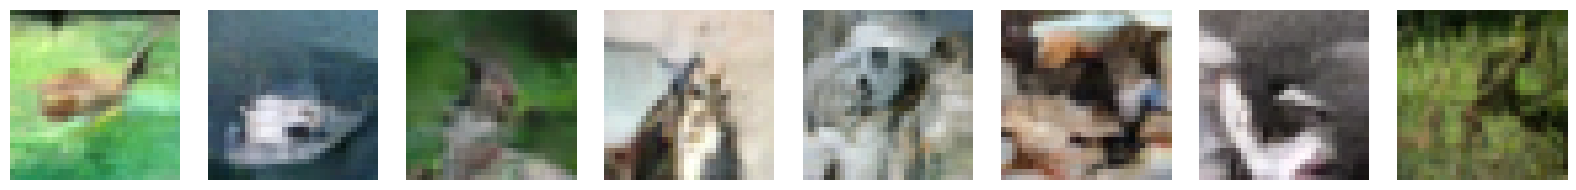

In [12]:
import matplotlib.pyplot as plt

num_samples = 8
samples = sample_ddpm(model, diffusion, shape=(num_samples, 3, 32, 32), device=device)

# 反归一化：从[-1,1]还原到[0,1]
samples = (samples.clamp(-1, 1) + 1) / 2

# [B,C,H,W] -> [B,H,W,C]，转到CPU再转numpy
samples = samples.cpu().permute(0, 2, 3, 1).numpy()

fig, axes = plt.subplots(1, num_samples, figsize=(num_samples * 2, 2))
for i, ax in enumerate(axes):
    ax.imshow(samples[i])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

num_samples = 8
samples = sample_ddim(model, diffusion, shape=(num_samples, 3, 32, 32), device=device)

# 反归一化：从[-1,1]还原到[0,1]
samples = (samples.clamp(-1, 1) + 1) / 2

# [B,C,H,W] -> [B,H,W,C]，转到CPU再转numpy
samples = samples.cpu().permute(0, 2, 3, 1).numpy()

fig, axes = plt.subplots(1, num_samples, figsize=(num_samples * 2, 2))
for i, ax in enumerate(axes):
    ax.imshow(samples[i])
    ax.axis("off")

plt.tight_layout()
plt.show()